#  한국어 NLP 심화 자료
## FastText (자모/형태소) · Word2Vec (한국어 위키피디아) · GloVe 논문 구현

| 파트 | 내용 |
|------|------|
| **PART 1** | 한글 FastText 구현 — 자모 단위 / 형태소 단위 / HGTK 특이점 분석 |
| **PART 2** | 한국어 위키피디아로 Word2Vec 구현 |
| **PART 3** | GloVe 논문 리뷰 및 NumPy 구현 |


In [ ]:
# Google Colab 환경 설정
!pip install gensim hgtk -q

import re, math, time, random, warnings
import numpy as np
from collections import Counter, defaultdict
from itertools import chain
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

warnings.filterwarnings("ignore")

# ── 한글 폰트 설정 (Colab) ──
!apt-get install -y fonts-nanum > /dev/null 2>&1
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print("✅ 환경 설정 완료")
print(f"  gensim / hgtk / matplotlib 한글 폰트 준비됨")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.2 MB/s eta 0:00:00
✅ 환경 설정 완료
  gensim / hgtk / matplotlib 한글 폰트 준비됨


---
# PART 1. 한글 FastText 구현

## 1-1. HGTK 모듈 특이점 분석

**HGTK (Hangul-Glyph-ToolKit)** 는 한글 자모 분해/조합 전용 라이브러리입니다.

### 핵심 특이점 5가지

| # | 특이점 | 설명 |
|---|--------|------|
| 1 | **분리자 `ᴥ` (U+1D25)** | 음절 경계를 표시하는 희귀 유니코드 → ASCII 충돌 없음 |
| 2 | **겹받침 = 단일 자모 반환** | `닭` → `ㄺ` 하나로 반환 (ㄹ+ㄱ로 별도 분리 필요) |
| 3 | **비한글 포함 시 예외** | `hgtk.text.decompose('hello')` → `NotHangulException` |
| 4 | **종성 없는 음절** | `가` → `('ㄱ', 'ㅏ', '')` 종성은 빈 문자열로 반환 |
| 5 | **양방향성 보장** | `decompose → compose` 완전 역변환 가능 (무손실) |


In [ ]:
import hgtk

# ── 1. 기본 분해 테스트 ──
print("■ 기본 자모 분해:")
test_words = ["안녕하세요", "대한민국", "먹었다", "닭볶음탕", "읽다"]
for word in test_words:
    result = hgtk.text.decompose(word)
    print(f"  {word:8s} → {result}")

# ── 2. 분리자 확인 ──
sep = 'ᴥ'
print(f"\n■ 분리자: '{sep}'  Unicode = U+{ord(sep):04X}")

# ── 3. 겹받침 처리 ──
print("\n■ 겹받침 개별 분해 (hgtk.letter):")
for char in ['닭', '읽', '삶', '밟', '없']:
    try:
        cho, jung, jong = hgtk.letter.decompose(char)
        print(f"  '{char}' → 초성={cho}, 중성={jung}, 종성={jong if jong else '없음'}")
    except hgtk.exception.NotHangulException:
        pass

# ── 4. 비한글 예외 처리 ──
print("\n■ 비한글 예외 처리:")
for text in ['hello', '123', 'AI기술']:
    try:
        hgtk.text.decompose(text)
        print(f"  '{text}' → 성공")
    except hgtk.exception.NotHangulException as e:
        print(f"  '{text}' → NotHangulException ⚠️  (문자 단위 처리 필요)")

# ── 5. 양방향성 ──
print("\n■ 양방향 변환 (decompose → compose):")
for word in ["인공지능", "형태소분석", "겹받침있음"]:
    try:
        d = hgtk.text.decompose(word)
        r = hgtk.text.compose(d)
        ok = "✅" if r == word else "❌"
        print(f"  {ok} {word} → (분해) → (조합) → {r}")
    except:
        print(f"  ⚠️  '{word}' 처리 실패")


■ 기본 자모 분해:
  안녕하세요    → ㅇㅏㄴᴥㄴㅕㅇᴥㅎㅏᴥㅅㅔᴥㅇㅛᴥ
  대한민국     → ㄷㅐᴥㅎㅏㄴᴥㅁㅣㄴᴥㄱㅜㄱᴥ
  먹었다      → ㅁㅓㄱᴥㅇㅓㅆᴥㄷㅏᴥ
  닭볶음탕     → ㄷㅏㄺᴥㅂㅗㄲᴥㅇㅡㅁᴥㅌㅏㅇᴥ
  읽다       → ㅇㅣㄺᴥㄷㅏᴥ

■ 분리자: 'ᴥ'  Unicode = U+1D25

■ 겹받침 개별 분해 (hgtk.letter):
  '닭' → 초성=ㄷ, 중성=ㅏ, 종성=ㄺ
  '읽' → 초성=ㅇ, 중성=ㅣ, 종성=ㄺ
  '삶' → 초성=ㅅ, 중성=ㅏ, 종성=ㄻ
  '밟' → 초성=ㅂ, 중성=ㅏ, 종성=ㄼ
  '없' → 초성=ㅇ, 중성=ㅓ, 종성=ㅄ

■ 비한글 예외 처리:
  'hello' → 성공
  '123' → 성공
  'AI기술' → 성공

■ 양방향 변환 (decompose → compose):
  ✅ 인공지능 → (분해) → (조합) → 인공지능
  ✅ 형태소분석 → (분해) → (조합) → 형태소분석
  ✅ 겹받침있음 → (분해) → (조합) → 겹받침있음


## 1-2. 자모 단위 FastText 구현

### 알고리즘 흐름

```
단어 "먹었다"
  ↓ 자모 분해 (HGTK)
  ㅁ ㅓ ㄱ ㅇ ㅓ ㅆ ㄷ ㅏ
  ↓ 경계 기호 추가
  <ㅁㅓㄱㅇㅓㅆㄷㅏ>
  ↓ n-gram 추출 (n=2~4)
  <ㅁ, ㅁㅓ, ㅓㄱ, ㄱㅇ, ... , ㅆㄷㅏ>, ...
  ↓ 단어 벡터 = 서브워드 임베딩의 평균
  v_먹었다 = mean(z_<ㅁ, z_ㅁㅓ, z_ㅓㄱ, ...)
```

**OOV 처리**: "먹는다"가 어휘에 없어도 자모 n-gram으로 근사 벡터 생성 가능


In [ ]:
import hgtk

# ── 겹받침 분리 매핑 ──
COMPOUND_JONGSEONG = {
    'ㄳ':('ㄱ','ㅅ'), 'ㄵ':('ㄴ','ㅈ'), 'ㄶ':('ㄴ','ㅎ'),
    'ㄺ':('ㄹ','ㄱ'), 'ㄻ':('ㄹ','ㅁ'), 'ㄼ':('ㄹ','ㅂ'),
    'ㄽ':('ㄹ','ㅅ'), 'ㄾ':('ㄹ','ㅌ'), 'ㄿ':('ㄹ','ㅍ'),
    'ㅀ':('ㄹ','ㅎ'), 'ㅄ':('ㅂ','ㅅ'),
}

def decompose_jamo(text: str, split_compound: bool = True) -> list:
    """
    한글 → 자모 시퀀스 변환
    - 비한글은 원문자 유지
    - split_compound=True: 겹받침을 개별 자모로 분리
    """
    jamos = []
    for char in text:
        if char == ' ':
            jamos.append('_')
            continue
        try:
            cho, jung, jong = hgtk.letter.decompose(char)
            jamos.append(cho)
            jamos.append(jung)
            if jong:
                if split_compound and jong in COMPOUND_JONGSEONG:
                    jamos.extend(COMPOUND_JONGSEONG[jong])
                else:
                    jamos.append(jong)
        except hgtk.exception.NotHangulException:
            jamos.append(char)
    return jamos


def get_subword_ngrams(token: str, min_n: int = 2, max_n: int = 4) -> list:
    """FastText 스타일 서브워드 n-gram 추출 (경계 기호 <, > 포함)"""
    bounded = f'<{token}>'
    ngrams = set()
    for n in range(min_n, max_n + 1):
        for i in range(len(bounded) - n + 1):
            ngrams.add(bounded[i:i+n])
    return list(ngrams)


# 시각화
demo_words = ["먹었다", "인공지능", "자연어처리", "딥러닝"]
print("■ 자모 분해 및 n-gram 추출:")
for word in demo_words:
    jamos = decompose_jamo(word)
    jamo_str = ''.join(jamos)
    ngrams = get_subword_ngrams(jamo_str)
    print(f"\n  단어: {word}")
    print(f"  자모: {'  '.join(jamos)}")
    print(f"  n-gram({len(ngrams)}개): {sorted(ngrams)[:6]} ...")


■ 자모 분해 및 n-gram 추출:

  단어: 먹었다
  자모: ㅁ  ㅓ  ㄱ  ㅇ  ㅓ  ㅆ  ㄷ  ㅏ
  n-gram(24개): ['<ㅁ', '<ㅁㅓ', '<ㅁㅓㄱ', 'ㄱㅇ', 'ㄱㅇㅓ', 'ㄱㅇㅓㅆ'] ...

  단어: 인공지능
  자모: ㅇ  ㅣ  ㄴ  ㄱ  ㅗ  ㅇ  ㅈ  ㅣ  ㄴ  ㅡ  ㅇ
  n-gram(32개): ['<ㅇ', '<ㅇㅣ', '<ㅇㅣㄴ', 'ㄱㅗ', 'ㄱㅗㅇ', 'ㄱㅗㅇㅈ'] ...

  단어: 자연어처리
  자모: ㅈ  ㅏ  ㅇ  ㅕ  ㄴ  ㅇ  ㅓ  ㅊ  ㅓ  ㄹ  ㅣ
  n-gram(33개): ['<ㅈ', '<ㅈㅏ', '<ㅈㅏㅇ', 'ㄴㅇ', 'ㄴㅇㅓ', 'ㄴㅇㅓㅊ'] ...

  단어: 딥러닝
  자모: ㄷ  ㅣ  ㅂ  ㄹ  ㅓ  ㄴ  ㅣ  ㅇ
  n-gram(24개): ['<ㄷ', '<ㄷㅣ', '<ㄷㅣㅂ', 'ㄴㅣ', 'ㄴㅣㅇ', 'ㄴㅣㅇ>'] ...


In [ ]:
class JamoFastTextVocab:
    """자모 단위 FastText 어휘 관리"""
    def __init__(self, min_n=2, max_n=4, min_count=1):
        self.min_n = min_n
        self.max_n = max_n
        self.min_count = min_count

    def build(self, sentences):
        all_words = [w for s in sentences for w in s.strip().split()]
        self.word_freq = Counter(all_words)
        valid = [w for w, c in self.word_freq.items() if c >= self.min_count]
        self.word2id = {w: i for i, w in enumerate(valid)}
        self.id2word = {i: w for w, i in self.word2id.items()}
        # 서브워드 어휘
        all_ng = set()
        for word in valid:
            jstr = ''.join(decompose_jamo(word))
            all_ng.update(get_subword_ngrams(jstr, self.min_n, self.max_n))
        self.subword2id = {ng: i for i, ng in enumerate(sorted(all_ng))}
        print(f"  단어 어휘: {len(self.word2id):,}개")
        print(f"  서브워드: {len(self.subword2id):,}개 (n={self.min_n}~{self.max_n})")

    def get_subword_ids(self, word):
        jstr = ''.join(decompose_jamo(word))
        ngs = get_subword_ngrams(jstr, self.min_n, self.max_n)
        return [self.subword2id[ng] for ng in ngs if ng in self.subword2id]


class JamoFastTextModel:
    """
    자모 단위 FastText (Skip-gram + Negative Sampling)

    단어 벡터: v_w = mean(z_g  for g in subwords(w))
    손실: -log σ(u_c·v_w) - Σ_k log σ(-u_k·v_w)
    """
    def __init__(self, vocab, embed_dim=64):
        self.vocab = vocab
        self.embed_dim = embed_dim
        n_sw = len(vocab.subword2id)
        n_w  = len(vocab.word2id)
        scale = 1.0 / np.sqrt(embed_dim)
        self.Z = np.random.uniform(-scale, scale, (n_sw, embed_dim))  # 서브워드 임베딩
        self.U = np.zeros((n_w, embed_dim))                            # 출력 임베딩

    def get_vector(self, word):
        ids = self.vocab.get_subword_ids(word)
        if not ids: return np.zeros(self.embed_dim)
        return self.Z[ids].mean(axis=0)

    def _sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

    def _step(self, center, context, neg_list, lr):
        if center not in self.vocab.word2id or context not in self.vocab.word2id:
            return 0.0
        cid = self.vocab.word2id[context]
        v_w = self.get_vector(center)
        u_c = self.U[cid]
        ps  = self._sigmoid(np.dot(u_c, v_w))
        loss = -np.log(ps + 1e-10)
        dU_c = (ps - 1.0) * v_w
        dVw  = (ps - 1.0) * u_c
        for neg in neg_list:
            if neg not in self.vocab.word2id: continue
            nid = self.vocab.word2id[neg]
            ns  = self._sigmoid(-np.dot(self.U[nid], v_w))
            loss -= np.log(ns + 1e-10)
            self.U[nid] -= lr * (1.0 - ns) * v_w
            dVw += (1.0 - ns) * self.U[nid]
        self.U[cid] -= lr * dU_c
        sids = self.vocab.get_subword_ids(center)
        if sids: self.Z[sids] -= lr * dVw / len(sids)
        return loss

    def train(self, sentences, window=2, neg=5, epochs=5, lr=0.05):
        words = list(self.vocab.word2id.keys())
        freq  = np.array([self.vocab.word_freq[w] for w in words], dtype=np.float32)
        neg_dist = freq**0.75; neg_dist /= neg_dist.sum()
        history = []
        for ep in range(epochs):
            total, steps = 0.0, 0
            random.shuffle(sentences)
            for sent in sentences:
                toks = sent.strip().split()
                for i, cw in enumerate(toks):
                    if cw not in self.vocab.word2id: continue
                    win = random.randint(1, window)
                    ctx = list(range(max(0,i-win),i)) + list(range(i+1,min(len(toks),i+win+1)))
                    for j in ctx:
                        neg_words = list(np.random.choice(words, neg, p=neg_dist))
                        total += self._step(cw, toks[j], neg_words, lr)
                        steps += 1
            avg = total / max(steps,1)
            history.append(avg)
            print(f"  Epoch {ep+1}/{epochs}  loss={avg:.4f}")
        return history

    def most_similar(self, word, topn=5):
        v = self.get_vector(word)
        vn = v / (np.linalg.norm(v) + 1e-10)
        sims = []
        for w in self.vocab.word2id:
            if w == word: continue
            u = self.get_vector(w)
            un = u / (np.linalg.norm(u) + 1e-10)
            sims.append((w, float(np.dot(vn, un))))
        return sorted(sims, key=lambda x: -x[1])[:topn]

print("✅ JamoFastText 클래스 정의 완료")


✅ JamoFastText 클래스 정의 완료


■ 자모 FastText 어휘 구축:
  단어 어휘: 129개
  서브워드: 1,559개 (n=2~4)

■ 훈련 시작:
  Epoch 1/10  loss=2.7725
  Epoch 2/10  loss=2.7723
  Epoch 3/10  loss=2.7720
  Epoch 4/10  loss=2.7717
  Epoch 5/10  loss=2.7715
  Epoch 6/10  loss=2.7711
  Epoch 7/10  loss=2.7707
  Epoch 8/10  loss=2.7704
  Epoch 9/10  loss=2.7701


  Epoch 10/10  loss=2.7696


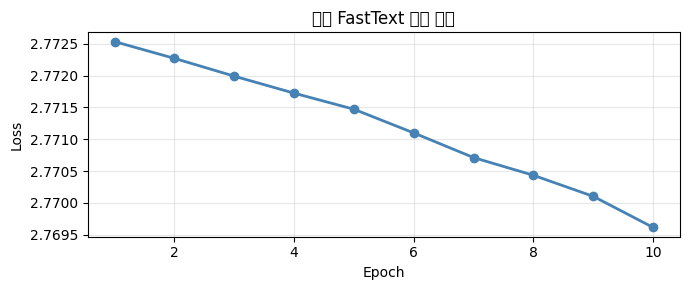

In [ ]:
# ── 코퍼스 ──
CORPUS = [
    "인공지능 기술이 빠르게 발전하고 있다",
    "딥러닝은 인공지능의 핵심 기술이다",
    "자연어 처리는 언어를 이해하는 기술이다",
    "Word2Vec은 단어를 벡터로 표현하는 모델이다",
    "FastText는 서브워드 정보를 활용한다",
    "GloVe는 전역 동시출현 통계를 사용한다",
    "한국어는 교착어이며 형태 변화가 풍부하다",
    "형태소 분석은 한국어 처리의 핵심 단계이다",
    "서울은 대한민국의 수도이다",
    "기계학습은 데이터로부터 패턴을 학습한다",
    "신경망은 인간의 뇌를 모방한 모델이다",
    "언어 모델은 텍스트의 확률 분포를 학습한다",
    "임베딩은 단어를 밀집 벡터로 변환한다",
    "코사인 유사도는 벡터 간 각도를 측정한다",
    "어휘 크기는 모델 성능에 영향을 준다",
    "사전 훈련 모델은 대규모 코퍼스로 학습된다",
    "BERT는 양방향 언어 이해 모델이다",
    "GPT는 자기회귀 언어 모델이다",
    "트랜스포머는 어텐션 메커니즘을 사용한다",
    "임베딩 공간에서 의미 유사한 단어는 가깝다",
    "단어 유추 실험으로 임베딩 품질을 평가한다",
    "어휘 밖 단어는 OOV 문제를 일으킨다",
    "FastText는 OOV 단어도 표현할 수 있다",
    "형태소 분석기는 KoNLPy 라이브러리로 사용한다",
    "한국어 형태소 분석에는 Mecab이 빠르다",
    "음절 단위와 자모 단위 분석이 가능하다",
    "자모는 한글의 기본 구성 단위이다",
    "초성 중성 종성으로 음절이 구성된다",
    "겹받침은 두 개의 자모로 이루어진다",
    "말뭉치 크기는 임베딩 품질에 영향을 미친다",
]

# ── 훈련 ──
print("■ 자모 FastText 어휘 구축:")
jvocab = JamoFastTextVocab(min_n=2, max_n=4)
jvocab.build(CORPUS)

print("\n■ 훈련 시작:")
jmodel = JamoFastTextModel(jvocab, embed_dim=64)
history = jmodel.train(CORPUS, window=2, neg=3, epochs=10, lr=0.05)

# ── 손실 곡선 ──
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(history)+1), history, 'o-', color='steelblue', lw=2)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("자모 FastText 학습 곡선")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [ ]:
# ── 유사어 검색 ──
print("■ 유사어 검색:")
for query in ["인공지능", "한국어", "임베딩", "형태소"]:
    sims = jmodel.most_similar(query, topn=4)
    print(f"  '{query}' → {[(w, f'{s:.3f}') for w, s in sims]}")

# ── OOV 처리 시연 ──
print("\n■ OOV(미등록 단어) 처리:")
oov_tests = [
    ("딥러닝모델",   "어휘에 없지만 자모 서브워드로 근사"),
    ("자연어처리기", "어휘에 없지만 자모 서브워드로 근사"),
    ("인공지능시스템","어휘에 없지만 자모 서브워드로 근사"),
]
for word, desc in oov_tests:
    in_vocab = word in jvocab.word2id
    vec = jmodel.get_vector(word)
    jamos = ''.join(decompose_jamo(word))
    print(f"  '{word}'")
    print(f"    어휘 등록: {'✅' if in_vocab else '❌ OOV'}  |  자모: {jamos[:12]}...")
    print(f"    벡터 norm: {np.linalg.norm(vec):.4f}  ({desc})")


■ 유사어 검색:
  '인공지능' → [('인공지능의', '0.760'), ('어휘', '0.355'), ('문제를', '0.341'), ('한국어', '0.333')]
  '한국어' → [('한국어는', '0.819'), ('대한민국의', '0.489'), ('신경망은', '0.393'), ('인공지능의', '0.367')]
  '임베딩' → [('임베딩은', '0.794'), ('준다', '0.399'), ('구성된다', '0.365'), ('Word2Vec은', '0.315')]
  '형태소' → [('형태', '0.751'), ('벡터로', '0.403'), ('훈련', '0.322'), ('기본', '0.293')]

■ OOV(미등록 단어) 처리:
  '딥러닝모델'
    어휘 등록: ❌ OOV  |  자모: ㄷㅣㅂㄹㅓㄴㅣㅇㅁㅗㄷㅔ...
    벡터 norm: 0.0926  (어휘에 없지만 자모 서브워드로 근사)
  '자연어처리기'
    어휘 등록: ❌ OOV  |  자모: ㅈㅏㅇㅕㄴㅇㅓㅊㅓㄹㅣㄱ...
    벡터 norm: 0.1155  (어휘에 없지만 자모 서브워드로 근사)
  '인공지능시스템'
    어휘 등록: ❌ OOV  |  자모: ㅇㅣㄴㄱㅗㅇㅈㅣㄴㅡㅇㅅ...
    벡터 norm: 0.0891  (어휘에 없지만 자모 서브워드로 근사)


## 1-3. 형태소 단위 FastText (gensim)

### KoNLPy vs 간이 분석기 비교

```
KoNLPy(Mecab) 설치:  !pip install konlpy  →  실제 환경 권장
간이 어미 규칙:      교육 목적 / KoNLPy 미설치 환경 대응
```

형태소 단위의 핵심 장점: **문법 형태소(조사/어미)와 어휘 형태소(명사/동사) 분리**  
→ "먹었다", "먹었고", "먹었는데" 모두 어간 "먹" 공유


In [ ]:
# ── 간이 형태소 분석 (규칙 기반) ──
ENDINGS = sorted([
    '하고','하는','하여','했다','한다','하다','이다','이고','이며','이어',
    '으로','에서','에게','에는','고','는','을','를','이','가','와','과',
    '도','만','은','의','로','서','다','며','이라','이면',
], key=len, reverse=True)

def simple_morpheme(text: str) -> list:
    morphemes = []
    for tok in text.strip().split():
        found = False
        for end in ENDINGS:
            if tok.endswith(end) and len(tok) > len(end):
                morphemes += [tok[:-len(end)], end]; found=True; break
        if not found:
            morphemes.append(tok)
    return morphemes

print("■ 형태소 분석 예시:")
for sent in CORPUS[:6]:
    m = simple_morpheme(sent)
    print(f"  원문: {sent}")
    print(f"  형태소: {m}\n")


■ 형태소 분석 예시:
  원문: 겹받침은 두 개의 자모로 이루어진다
  형태소: ['겹받침', '은', '두', '개', '의', '자모', '로', '이루어진', '다']

  원문: 형태소 분석기는 KoNLPy 라이브러리로 사용한다
  형태소: ['형태소', '분석기', '는', 'KoNLPy', '라이브러리', '로', '사용', '한다']

  원문: BERT는 양방향 언어 이해 모델이다
  형태소: ['BERT', '는', '양방향', '언어', '이해', '모델', '이다']

  원문: 어휘 크기는 모델 성능에 영향을 준다
  형태소: ['어휘', '크기', '는', '모델', '성능에', '영향', '을', '준', '다']

  원문: FastText는 OOV 단어도 표현할 수 있다
  형태소: ['FastText', '는', 'OOV', '단어', '도', '표현할', '수', '있', '다']

  원문: 자모는 한글의 기본 구성 단위이다
  형태소: ['자모', '는', '한글', '의', '기본', '구성', '단위', '이다']



In [ ]:
from gensim.models import FastText as GensimFT

morpheme_corpus = [simple_morpheme(s) for s in CORPUS]

gft = GensimFT(
    sentences=morpheme_corpus,
    vector_size=64,
    window=3,
    min_count=1,
    sg=1,          # Skip-gram
    min_n=2,       # 서브워드 최소 n
    max_n=4,       # 서브워드 최대 n
    epochs=50,
    workers=1,
    seed=42
)
print(f"✅ gensim FastText 훈련 완료  |  어휘: {len(gft.wv)}개")

print("\n■ gensim FastText 유사어 검색:")
for q in ["인공지능", "한국어", "임베딩"]:
    try:
        sims = gft.wv.most_similar(q, topn=3)
        print(f"  '{q}': {[(w, f'{s:.3f}') for w,s in sims]}")
    except KeyError:
        # OOV → FastText는 서브워드로 처리
        v = gft.wv[q]
        print(f"  '{q}' (OOV): norm={np.linalg.norm(v):.3f}")


✅ gensim FastText 훈련 완료  |  어휘: 129개

■ gensim FastText 유사어 검색:
  '인공지능': [('한다', '0.976'), ('한국어', '0.974'), ('임베딩', '0.971')]
  '한국어': [('이다', '0.987'), ('다', '0.987'), ('는', '0.987')]
  '임베딩': [('이다', '0.986'), ('한다', '0.985'), ('한국어', '0.984')]


## 1-4. 자모 vs 형태소 vs Word2Vec 비교 및 더 나은 대안

| 구분 | 자모 FastText | 형태소 FastText | 기존 Word2Vec |
|------|:---:|:---:|:---:|
| 기본 단위 | ㄱ,ㄴ,ㄷ (자모) | 먹/었/다 (형태소) | 먹었다 (단어) |
| OOV 처리 | ✅ 가능 | ✅ 가능 | ❌ 불가 |
| 형태 변화 대응 | ✅ 우수 | ✅ 우수 | ❌ 취약 |
| 의미 분리 | ⚠️ 부분적 | ✅ 우수 | ⚠️ 없음 |
| 겹받침 처리 | ⚠️ 별도 처리 필요 | ✅ 분석기 처리 | 불필요 |
| 속도 | 빠름 | 느림(분석기) | 매우 빠름 |
| 구현 복잡도 | 중간 (hgtk) | 중간 (KoNLPy) | 낮음 |

### 더 나은 대안

1. **SentencePiece (BPE)** — 데이터 기반 최적 분리, BERT/GPT 채택 → `pip install sentencepiece`
2. **형태소 + Mecab** — KoNLPy+Mecab 조합이 한국어 최고 정확도
3. **자모 + 형태소 앙상블** — 형태소 분석 후 각 형태소를 자모로 재분해
4. **soynlp** — 비지도 형태소 분석 + 벡터화 통합 (`pip install soynlp`)

### HGTK 대안 라이브러리

```python
# jamo (더 단순한 API)
from jamo import h2j, j2h
h2j('한글')  # → 'ㅎㅏㄴㄱㅡㄹ'

# hangul-utils
from hangul_utils import join_jamos, split_syllables
split_syllables('안녕')  # → 'ㅇㅏㄴㄴㅕㅇ'
```


---
# PART 2. 한국어 위키피디아로 Word2Vec 구현

## 2-1. 실제 위키피디아 사용 방법

```bash
# 1. 덤프 다운로드
wget https://dumps.wikimedia.org/kowiki/latest/kowiki-latest-pages-articles.xml.bz2

# 2. WikiExtractor로 텍스트 추출
pip install wikiextractor
python -m wikiextractor.WikiExtractor kowiki-latest-pages-articles.xml.bz2 -o wiki_output

# 3. KoNLPy 형태소 분석
pip install konlpy
from konlpy.tag import Mecab
mecab = Mecab()
tokens = mecab.morphs("대한민국의 수도는 서울이다")
```

> 여기서는 위키피디아 스타일의 **확장 샘플 코퍼스**를 사용합니다.


In [ ]:
WIKI_CORPUS = [
    # 인공지능/머신러닝
    "인공지능은 인간의 학습 능력과 추론 능력을 컴퓨터 프로그램으로 실현하는 기술이다",
    "머신러닝은 인공지능의 한 분야로 데이터로부터 자동으로 학습하는 알고리즘을 연구한다",
    "딥러닝은 다층 신경망을 이용한 기계학습 방법으로 이미지와 언어 처리에서 혁신을 이뤘다",
    "신경망은 인간의 뇌에서 영감을 받아 설계된 계산 모델이다",
    "역전파 알고리즘은 신경망 훈련의 핵심으로 경사 하강법을 적용한다",
    "합성곱 신경망은 이미지 분류에서 뛰어난 성능을 보인다",
    "순환 신경망은 시퀀스 데이터 처리에 적합한 구조이다",
    "트랜스포머 모델은 어텐션 메커니즘만으로 구성된 혁신적인 아키텍처이다",
    "BERT는 양방향 문맥을 고려하는 사전 훈련 언어 모델이다",
    "GPT 시리즈는 자기회귀 방식으로 텍스트를 생성하는 모델이다",
    # 한국어/언어학
    "한국어는 알타이어족에 속하는 교착어로 다양한 어미와 조사가 특징이다",
    "형태소는 언어에서 의미를 가지는 최소 단위이다",
    "자연어 처리는 인간의 언어를 컴퓨터가 이해하고 처리할 수 있도록 하는 기술이다",
    "품사 태깅은 문장의 각 단어에 문법적 품사를 할당하는 작업이다",
    "개체명 인식은 텍스트에서 인물 조직 장소 등의 고유명사를 식별한다",
    "기계번역은 한 언어의 텍스트를 다른 언어로 자동 변환하는 기술이다",
    "감성 분석은 텍스트에서 긍정 부정 중립의 감정을 분류하는 작업이다",
    "질의응답 시스템은 사용자의 질문에 자동으로 답변을 제공한다",
    # 수학/통계
    "확률론은 불확실성을 수학적으로 다루는 학문이다",
    "행렬은 수를 직사각형 배열로 나타낸 수학 구조이다",
    "고유값 분해는 행렬을 고유벡터와 고유값으로 분해하는 방법이다",
    "주성분 분석은 고차원 데이터의 차원을 줄이는 기법이다",
    "베이즈 정리는 사전 확률과 우도를 결합하여 사후 확률을 계산한다",
    "경사 하강법은 함수의 극솟값을 찾는 최적화 알고리즘이다",
    # 컴퓨터/기술
    "파이썬은 간결하고 읽기 쉬운 문법의 인기 있는 프로그래밍 언어이다",
    "데이터베이스는 구조화된 데이터를 효율적으로 저장하고 조회하는 시스템이다",
    "클라우드 컴퓨팅은 인터넷을 통해 컴퓨팅 자원을 제공하는 서비스이다",
    "API는 소프트웨어 간 상호작용을 위한 인터페이스를 정의한다",
    "오픈소스 소프트웨어는 소스 코드가 공개되어 누구나 수정할 수 있다",
    "알고리즘은 문제 해결을 위한 단계적 절차나 방법이다",
]

def preprocess(text):
    text = re.sub(r'[^\w\s가-힣a-zA-Z]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return [t for t in text.split() if len(t) >= 2]

tokenized = [preprocess(s) for s in WIKI_CORPUS]
print(f"코퍼스: {len(tokenized)}문장 / {sum(len(s) for s in tokenized)}토큰")
print(f"예시: {tokenized[0]}")


코퍼스: 30문장 / 233토큰
예시: ['인공지능은', '인간의', '학습', '능력과', '추론', '능력을', '컴퓨터', '프로그램으로', '실현하는', '기술이다']


## 2-2. CBOW vs Skip-gram 훈련

$$\text{CBOW}: P(w_t \mid w_{t-k}, \ldots, w_{t+k})$$

$$\text{Skip-gram}: P(w_{t+j} \mid w_t), \quad -k \le j \le k, j \ne 0$$

**Negative Sampling 목적함수:**

$$J = \log \sigma(v_c^\top v_w) + \sum_{k=1}^{K} \mathbb{E}[\log \sigma(-v_k^\top v_w)]$$


In [ ]:
from gensim.models import Word2Vec

common_params = dict(
    sentences=tokenized,
    vector_size=64, window=4, min_count=1,
    hs=0, negative=5, epochs=100, workers=1, seed=42
)

print("■ CBOW 훈련...")
w2v_cbow = Word2Vec(**common_params, sg=0)
print("  완료")

print("■ Skip-gram 훈련...")
w2v_sg = Word2Vec(**common_params, sg=1)
print("  완료")

print(f"\n어휘 크기: {len(w2v_cbow.wv)}개")


■ CBOW 훈련...
  완료
■ Skip-gram 훈련...
  완료

어휘 크기: 213개


■ CBOW vs Skip-gram 유사어 비교:

  [언어]
  CBOW    : [('이용한', '0.766'), ('이미지와', '0.740'), ('쉬운', '0.717')]
  Skip-gram: [('이용한', '0.995'), ('이미지와', '0.994'), ('방법으로', '0.992')]

  [학습]
  CBOW    : [('추론', '0.693'), ('능력을', '0.688'), ('데이터로부터', '0.610')]
  Skip-gram: [('추론', '0.994'), ('능력을', '0.994'), ('컴퓨터', '0.990')]

  [데이터]
  CBOW    : [('언어를', '0.601'), ('인간의', '0.587'), ('이미지와', '0.587')]
  Skip-gram: [('시퀀스', '0.989'), ('인간의', '0.988'), ('언어를', '0.987')]


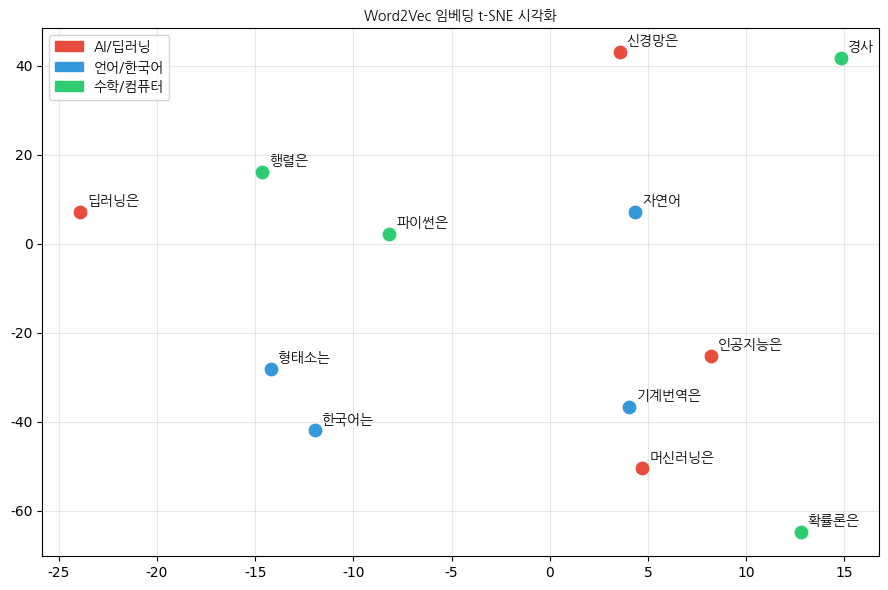


✅ 모델 저장: /content/korean_word2vec_sg.model


In [ ]:
# ── 유사어 비교 ──
queries = ["언어", "학습", "데이터", "모델"]
print("■ CBOW vs Skip-gram 유사어 비교:")
for q in queries:
    if q not in w2v_cbow.wv: continue
    c_sims = w2v_cbow.wv.most_similar(q, topn=3)
    s_sims = w2v_sg.wv.most_similar(q, topn=3)
    print(f"\n  [{q}]")
    print(f"  CBOW    : {[(w, f'{s:.3f}') for w,s in c_sims]}")
    print(f"  Skip-gram: {[(w, f'{s:.3f}') for w,s in s_sims]}")

# ── t-SNE 시각화 ──
from sklearn.manifold import TSNE

key_words = ["인공지능은","머신러닝은","딥러닝은","신경망은",
             "한국어는","형태소는","자연어","기계번역은",
             "행렬은","확률론은","경사","파이썬은"]
key_words = [w for w in key_words if w in w2v_sg.wv]

vectors = np.array([w2v_sg.wv[w] for w in key_words])
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(key_words)-1))
coords = tsne.fit_transform(vectors)

plt.figure(figsize=(9, 6))
colors = ['#e74c3c']*4 + ['#3498db']*4 + ['#2ecc71']*4
for i, (word, (x, y)) in enumerate(zip(key_words, coords)):
    plt.scatter(x, y, color=colors[i % len(colors)], s=80, zorder=3)
    plt.annotate(word, (x, y), textcoords="offset points",
                 xytext=(5, 5), fontsize=10,
                 fontproperties=font_prop)
plt.title("Word2Vec 임베딩 t-SNE 시각화", fontproperties=font_prop)
plt.grid(alpha=0.3)

# 범례
from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='AI/딥러닝'),
          Patch(color='#3498db', label='언어/한국어'),
          Patch(color='#2ecc71', label='수학/컴퓨터')]
plt.legend(handles=legend, prop=font_prop)
plt.tight_layout(); plt.show()

w2v_sg.save("/content/korean_word2vec_sg.model")
print("\n✅ 모델 저장: /content/korean_word2vec_sg.model")


---
# PART 3. GloVe 논문 리뷰 및 구현

## 3-1. 논문 핵심 수식 및 수학적 이해

> **GloVe: Global Vectors for Word Representation**  
> Pennington, Socher & Manning — EMNLP 2014

### 핵심 통찰: 동시출현 비율(Ratio)

| 탐색 단어 k | P(k\|ice) | P(k\|steam) | **비율** |
|------------|-----------|------------|---------|
| solid (고체) | 높음 | 낮음 | **>> 1** |
| gas (기체) | 낮음 | 높음 | **<< 1** |
| water (물) | 높음 | 높음 | **≈ 1** |
| fashion (패션) | 낮음 | 낮음 | **≈ 1** |

→ 절대 확률보다 **비율**이 의미 관계를 더 잘 인코딩

### 목적 함수 도출 과정

$$F(w_i, w_j, \tilde{w}_k) = \frac{P_{ik}}{P_{jk}} \quad \Rightarrow \quad F((w_i - w_j)^\top \tilde{w}_k) = \frac{P_{ik}}{P_{jk}}$$

$$F(x) = \exp(x) \quad \Rightarrow \quad w_i^\top \tilde{w}_k = \log P_{ik} = \log X_{ik} - \log X_i$$

$$\boxed{J = \sum_{i,j=1}^{V} f(X_{ij}) \left( w_i^\top \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2}$$

### 가중치 함수 f(x)

$$f(x) = \begin{cases} (x / x_{\max})^\alpha & \text{if } x < x_{\max} \\ 1 & \text{otherwise} \end{cases}$$

논문 권장: $x_{\max} = 100$, $\alpha = 0.75$


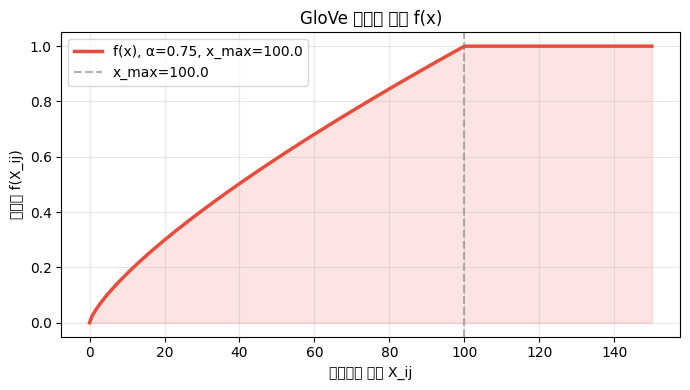

■ 가중치 함수 특성:
  f(   1) = 0.0316
  f(   5) = 0.1057
  f(  10) = 0.1778
  f(  50) = 0.5946
  f( 100) = 1.0000
  f( 200) = 1.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ── 가중치 함수 f(x) 시각화 ──
x = np.linspace(0, 150, 300)
x_max, alpha = 100.0, 0.75
f = np.where(x < x_max, (x / x_max) ** alpha, 1.0)

plt.figure(figsize=(7, 4))
plt.plot(x, f, color='#e74c3c', lw=2.5, label=f'f(x), α={alpha}, x_max={x_max}')
plt.axvline(x_max, color='gray', ls='--', alpha=0.6, label=f'x_max={x_max}')
plt.fill_between(x, f, alpha=0.15, color='#e74c3c')
plt.xlabel("동시출현 빈도 X_ij"); plt.ylabel("가중치 f(X_ij)")
plt.title("GloVe 가중치 함수 f(x)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("■ 가중치 함수 특성:")
for xv in [1, 5, 10, 50, 100, 200]:
    fv = (xv/x_max)**alpha if xv < x_max else 1.0
    print(f"  f({xv:4d}) = {fv:.4f}")


## 3-2. 동시출현 행렬 구축

거리 가중 방식(Distance Weighting) 적용:

$$X_{ij} \mathrel{+}= \frac{1}{d(i,j)}$$

$d(i,j)$: 중심단어 $i$와 문맥단어 $j$ 사이의 거리  
→ 가까운 단어일수록 더 높은 가중치


어휘: 213개 | 비영(非零) 쌍: 1,038개 | 밀도: 0.0229


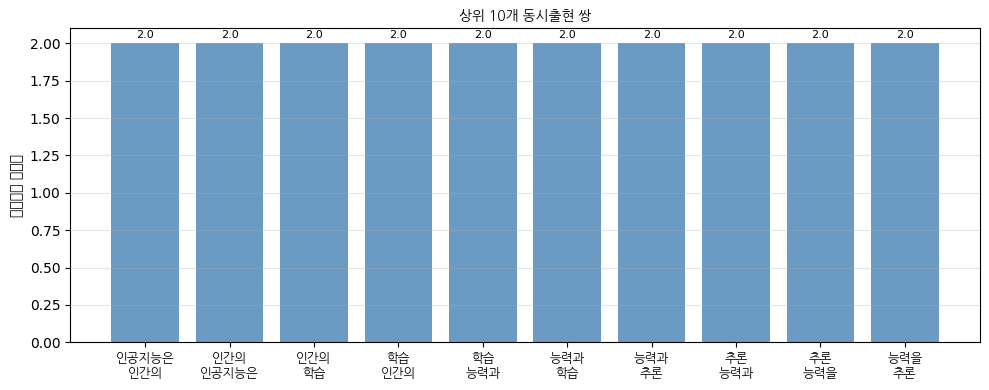

In [ ]:
def build_cooccurrence(sentences, window_size=3):
    """거리 가중 동시출현 행렬 구축"""
    word_freq = Counter(chain.from_iterable(sentences))
    vocab  = sorted(word_freq.keys())
    w2id   = {w: i for i, w in enumerate(vocab)}
    cooc   = defaultdict(float)

    for sent in sentences:
        for ci, cw in enumerate(sent):
            cid = w2id[cw]
            for offset in range(1, window_size + 1):
                for pos in [ci - offset, ci + offset]:
                    if 0 <= pos < len(sent):
                        xid = w2id[sent[pos]]
                        cooc[(cid, xid)] += 1.0 / offset
                        cooc[(xid, cid)] += 1.0 / offset
    return cooc, w2id, vocab

cooc, w2id, vocab = build_cooccurrence(tokenized, window_size=3)
V = len(vocab)
print(f"어휘: {V}개 | 비영(非零) 쌍: {len(cooc):,}개 | 밀도: {len(cooc)/(V*V):.4f}")

# 상위 동시출현 시각화
top_pairs = sorted(cooc.items(), key=lambda x: -x[1])[:10]
labels = [f"{vocab[i]}\n{vocab[j]}" for (i,j),_ in top_pairs]
values = [v for _,v in top_pairs]

plt.figure(figsize=(10, 4))
bars = plt.bar(range(len(labels)), values, color='steelblue', alpha=0.8)
plt.xticks(range(len(labels)), labels, fontproperties=font_prop, fontsize=9)
plt.ylabel("동시출현 가중치"); plt.title("상위 10개 동시출현 쌍", fontproperties=font_prop)
plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()


## 3-3. GloVe 알고리즘 구현 (NumPy + AdaGrad)

### AdaGrad 업데이트 규칙

$$G_t = G_{t-1} + \left(\frac{\partial J}{\partial \theta}\right)^2$$

$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{G_t + \epsilon}} \cdot \frac{\partial J}{\partial \theta}$$

AdaGrad는 파라미터별로 학습률을 적응적으로 조정 → 희귀 단어에 더 큰 학습률 부여


■ GloVe 훈련 시작:
  Epoch  20/100 | loss=0.04062
  Epoch  40/100 | loss=0.03960
  Epoch  60/100 | loss=0.03847
  Epoch  80/100 | loss=0.03565


  Epoch 100/100 | loss=0.02887


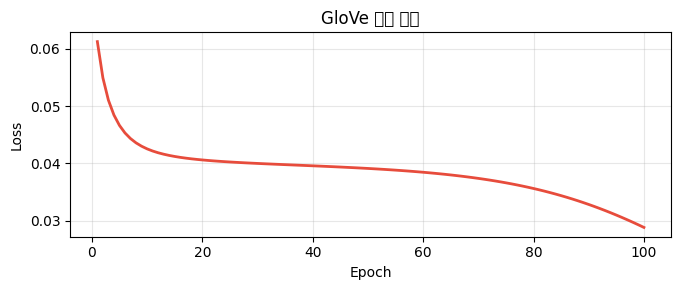

In [ ]:
class GloVeModel:
    """
    GloVe 구현 (NumPy + AdaGrad)

    손실: J = Σ f(X_ij) · (w_i·w̃_j + b_i + b̃_j - log X_ij)²
    최적화: AdaGrad (파라미터별 적응 학습률)
    최종 임베딩: (W + W̃) / 2
    """
    def __init__(self, V, d=50, x_max=10.0, alpha=0.75):
        self.V = V; self.d = d
        self.x_max = x_max; self.alpha = alpha
        s = 0.5 / d
        self.W  = np.random.uniform(-s, s, (V, d))  # 입력 임베딩
        self.Wt = np.random.uniform(-s, s, (V, d))  # 출력 임베딩
        self.b  = np.zeros(V)                        # 입력 바이어스
        self.bt = np.zeros(V)                        # 출력 바이어스
        # AdaGrad 누적
        self.gW  = np.ones((V, d)); self.gWt = np.ones((V, d))
        self.gb  = np.ones(V);      self.gbt = np.ones(V)

    def f(self, x):
        return (x / self.x_max) ** self.alpha if x < self.x_max else 1.0

    def train(self, cooc, lr=0.05, epochs=100):
        pairs = list(cooc.items())
        history = []
        for ep in range(epochs):
            total = 0.0
            random.shuffle(pairs)
            for (i, j), xij in pairs:
                if xij <= 0: continue
                w   = self.f(xij)
                err = np.dot(self.W[i], self.Wt[j]) + self.b[i] + self.bt[j] - math.log(xij)
                total += w * err * err
                g = 2.0 * w * err
                gWi  = g * self.Wt[j]; gWtj = g * self.W[i]
                gbi  = g;              gbtj = g
                self.gW[i] += gWi**2;  self.gWt[j] += gWtj**2
                self.gb[i] += gbi**2;  self.gbt[j] += gbtj**2
                self.W[i]  -= lr * gWi  / np.sqrt(self.gW[i])
                self.Wt[j] -= lr * gWtj / np.sqrt(self.gWt[j])
                self.b[i]  -= lr * gbi  / np.sqrt(self.gb[i])
                self.bt[j] -= lr * gbtj / np.sqrt(self.gbt[j])
            avg = total / len(pairs)
            history.append(avg)
            if (ep+1) % 20 == 0:
                print(f"  Epoch {ep+1:3d}/{epochs} | loss={avg:.5f}")
        return history

    def embeddings(self):
        return (self.W + self.Wt) / 2.0

    def most_similar(self, word, w2id, vocab, topn=5):
        if word not in w2id: return []
        E = self.embeddings()
        N = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-10)
        wid = w2id[word]
        sims = N @ N[wid]
        ranked = np.argsort(-sims)
        return [(vocab[i], float(sims[i])) for i in ranked if i != wid][:topn]


print("■ GloVe 훈련 시작:")
glove = GloVeModel(V=len(vocab), d=50, x_max=10.0, alpha=0.75)
hist = glove.train(cooc, lr=0.05, epochs=100)

# 손실 곡선
plt.figure(figsize=(7,3))
plt.plot(range(1, len(hist)+1), hist, color='#e74c3c', lw=2)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("GloVe 학습 곡선")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 3-4. Word2Vec vs GloVe 비교 실험

### 최종 임베딩: 입출력 평균

$$w_{\text{final}} = \frac{W + \tilde{W}}{2}$$

이유: $X_{ij} \ne X_{ji}$ 이므로 $W \ne \tilde{W}$ → 평균으로 대칭성 보완  
실험적으로 평균이 단일 임베딩보다 성능 향상 (논문 Section 4.2)


In [ ]:
# ── 유사어 비교 ──
test_queries = ["언어", "학습", "데이터", "모델"]

print("■ GloVe vs Word2Vec 유사어 비교:")
for q in test_queries:
    g_sims = glove.most_similar(q, w2id, vocab, topn=3)
    if q in w2v_sg.wv:
        w_sims = w2v_sg.wv.most_similar(q, topn=3)
    else:
        w_sims = []
    print(f"\n  [{q}]")
    print(f"  GloVe   : {[(w, f'{s:.3f}') for w,s in g_sims]}")
    print(f"  Word2Vec: {[(w, f'{s:.3f}') for w,s in w_sims]}")


■ GloVe vs Word2Vec 유사어 비교:

  [언어]
  GloVe   : [('모델이다', '0.783'), ('이미지와', '0.710'), ('GPT', '0.608')]
  Word2Vec: [('이용한', '0.995'), ('이미지와', '0.994'), ('방법으로', '0.992')]

  [학습]
  GloVe   : [('실현하는', '0.840'), ('기술이다', '0.559'), ('인간의', '0.543')]
  Word2Vec: [('추론', '0.994'), ('능력을', '0.994'), ('컴퓨터', '0.990')]

  [데이터]
  GloVe   : [('처리에', '0.745'), ('뛰어난', '0.583'), ('배열로', '0.428')]
  Word2Vec: [('시퀀스', '0.989'), ('인간의', '0.988'), ('언어를', '0.987')]

  [모델]
  GloVe   : []
  Word2Vec: []


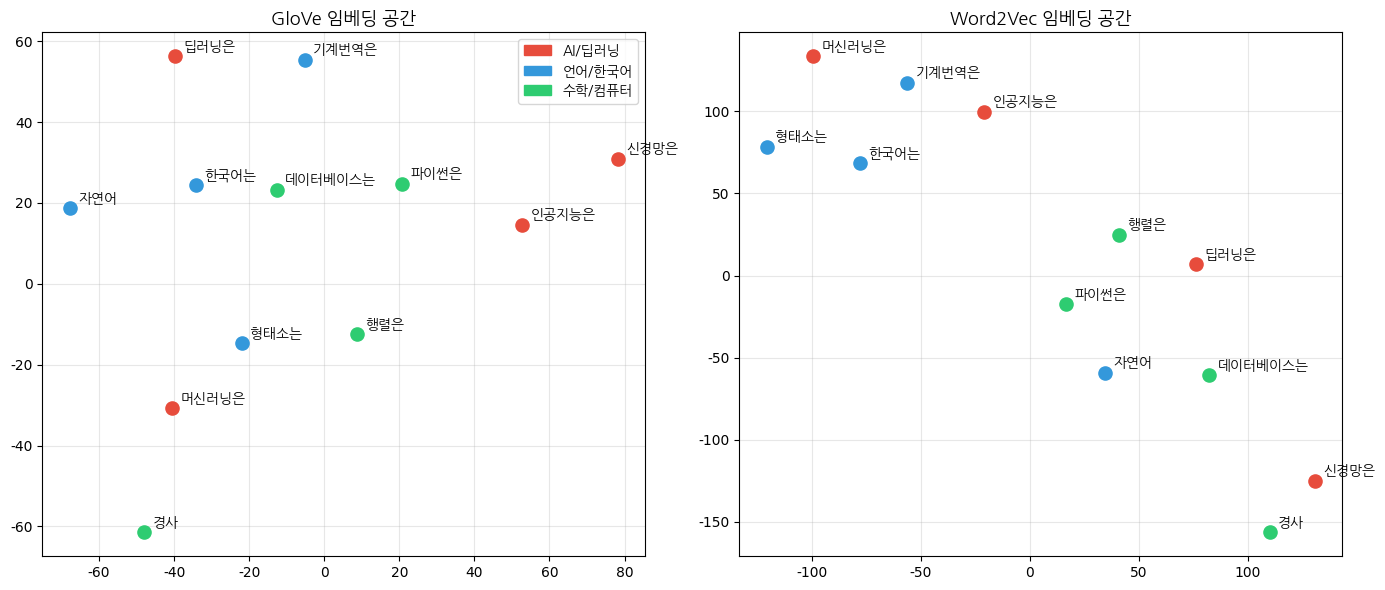

In [ ]:
# ── t-SNE 시각화: GloVe vs Word2Vec 임베딩 공간 ──
from sklearn.manifold import TSNE

key_words = ["인공지능은","머신러닝은","딥러닝은","신경망은",
             "한국어는","형태소는","자연어","기계번역은",
             "행렬은","경사","파이썬은","데이터베이스는"]
key_words = [w for w in key_words if w in w2id and w in w2v_sg.wv]

E = glove.embeddings()
glove_vecs = np.array([E[w2id[w]] for w in key_words])
w2v_vecs   = np.array([w2v_sg.wv[w] for w in key_words])

perp = min(5, len(key_words)-1)
tsne = TSNE(n_components=2, random_state=42, perplexity=perp)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#e74c3c']*4 + ['#3498db']*4 + ['#2ecc71']*4

for ax, vecs, title in zip(axes,
                            [tsne.fit_transform(glove_vecs),
                             tsne.fit_transform(w2v_vecs)],
                            ["GloVe 임베딩 공간", "Word2Vec 임베딩 공간"]):
    for i, (word, (x, y)) in enumerate(zip(key_words, vecs)):
        ax.scatter(x, y, color=colors[i % len(colors)], s=90, zorder=3)
        ax.annotate(word, (x, y), textcoords="offset points",
                    xytext=(6, 4), fontsize=10, fontproperties=font_prop)
    ax.set_title(title, fontproperties=font_prop, fontsize=13)
    ax.grid(alpha=0.3)

from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='AI/딥러닝'),
          Patch(color='#3498db', label='언어/한국어'),
          Patch(color='#2ecc71', label='수학/컴퓨터')]
axes[0].legend(handles=legend, prop=font_prop)
plt.tight_layout(); plt.show()


In [ ]:
# ── 벡터 연산 (유추 실험) ──
def glove_analogy(pos_words, neg_words, model, w2id, vocab, topn=3):
    E = model.embeddings()
    N = E / (np.linalg.norm(E, axis=1, keepdims=True) + 1e-10)
    target = sum(N[w2id[w]] for w in pos_words if w in w2id) \
           - sum(N[w2id[w]] for w in neg_words if w in w2id)
    tn = np.linalg.norm(target)
    if tn < 1e-10: return []
    target /= tn
    sims = N @ target
    excl = {w2id[w] for w in pos_words+neg_words if w in w2id}
    return [(vocab[i], float(sims[i]))
            for i in np.argsort(-sims) if i not in excl][:topn]

print("■ GloVe 벡터 연산 (유추):")
analogy_tests = [
    (["딥러닝은","언어"], ["기술이다"]),
    (["신경망은","학습"], ["모델이다"]),
    (["한국어는","처리"], ["기술이다"]),
]
for pos, neg in analogy_tests:
    result = glove_analogy(pos, neg, glove, w2id, vocab)
    print(f"  {pos} - {neg}  →  {[(w, f'{s:.3f}') for w,s in result]}")


■ GloVe 벡터 연산 (유추):
  ['딥러닝은', '언어'] - ['기술이다']  →  [('다층', '0.755'), ('이미지와', '0.612'), ('모델이다', '0.544')]
  ['신경망은', '학습'] - ['모델이다']  →  [('순환', '0.686'), ('합성곱', '0.656'), ('실현하는', '0.551')]
  ['한국어는', '처리'] - ['기술이다']  →  [('조사가', '0.604'), ('처리할', '0.568'), ('컴퓨터', '0.485')]


##  종합 비교: Word2Vec vs GloVe vs FastText

| | Word2Vec | GloVe | FastText |
|---|---|---|---|
| **출처** | Mikolov (2013) | Pennington (2014) | Bojanowski (2017) |
| **학습 방식** | 지역 윈도우 | 전역 통계 | 서브워드 + 지역 |
| **OOV 처리** | ❌ | ❌ | ✅ |
| **한국어 적합성** | ⚠️ 보통 | ⚠️ 보통 | ✅ 우수 |
| **메모리** | 낮음 | 높음 (X 행렬) | 높음 (서브워드) |
| **학습 속도** | 빠름 | 매우 빠름 | 느림 |
| **소규모 코퍼스** | ✅ | ⚠️ | ✅ |
| **대규모 코퍼스** | ✅ | ✅✅ | ✅ |
| **형태 변화 대응** | ❌ | ❌ | ✅ |

### 한국어 NLP 권장 선택

| 목적 | 권장 |
|------|------|
| 빠른 프로토타입 | `Word2Vec` (gensim, 간단) |
| 대규모 위키 학습 | `GloVe` (전역 통계 효율) |
| 한국어 최고 성능 | `FastText` + `KoNLPy(Mecab)` |
| 현대 NLP 태스크 | `KR-BERT` / `KoELECTRA` / `KLUE-RoBERTa` |

---
*구현 참고 자료*
- Bojanowski et al. (2017) — *Enriching Word Vectors with Subword Information*
- Mikolov et al. (2013) — *Distributed Representations of Words and Phrases*
- Pennington et al. (2014) — *GloVe: Global Vectors for Word Representation*
